# DEG analysis for IN subclusters using DEseq2

Script to calculate DEGs in IN subclusters between conditions

## Loading packages

In [2]:
import scanpy as sc
import decoupler as dc

# Only needed for processing
import numpy as np
import pandas as pd

# Needed for some plotting
import matplotlib.pyplot as plt

# Plotting options, change to your liking
sc.settings.set_figure_params(dpi=200, frameon=False)
sc.set_figure_params(dpi=200)
sc.set_figure_params(figsize=(4, 4))

## Loading the data

In [22]:
import scanpy as sc
import pandas as pd
import os
adata = sc.read('/wynton/scratch/jding/brainchromatin/HM2D/D7-filtered_guides.IN.h5ad')
adata.obs['Gene_target'] = adata.obs['gene_NKS'] 
targets = [x for x in adata.obs['Gene_target'].unique() if x in adata.var_names]
targets.append('non-targeting')
adata = adata[adata.obs['Gene_target'].isin(targets)]
adata.obs['predictions'] = adata.obs['subtype']
adata.obs['perturbation'] = ['Perturbed' if x in ['IN_LMO1/RIC3','IN_CALB2/SPOCK1'] else 'WT' for x in adata.obs['predictions']]

/scratch/jding/ipykernel_2644096/1239882985.py:9: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  adata.obs['predictions'] = adata.obs['subtype']


In [2]:
import scanpy as sc
import pandas as pd
import os
adata = sc.read('/wynton/group/pollen/jding/brainchromatin/Li/HM2D_IN_query.h5ad')
adata.obs['Gene_target'] = adata.obs['gene_NKS'] 
targets = [x for x in adata.obs['Gene_target'].unique() if x in adata.var_names]
targets.append('non-targeting')
adata = adata[adata.obs['Gene_target'].isin(targets)]
adata.obs['sex'] = [x.split('-')[-1] for x in adata.obs['individual']]
adata.obs['stage'] = [x.split('#')[0] for x in adata.obs['individual']]
adata.obs['perturbation'] = ['Perturbed' if x in ['IN_LMO1/RIC3','IN_CALB2/SPOCK1'] else 'WT' for x in adata.obs['predictions']]

adata = adata[adata.obs['species'] == 'human']

/wynton/home/pollenlab/jding/miniconda3/envs/pertpy/lib/python3.9/site-packages/anndata/__init__.py:51: FutureWarning: `anndata.read` is deprecated, use `anndata.read_h5ad` instead. `ad.read` will be removed in mid 2024.
  warnings.warn(
/scratch/jding/ipykernel_2116948/3621197811.py:9: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  adata.obs['sex'] = [x.split('-')[-1] for x in adata.obs['individual']]


In [23]:
import scanpy as sc
import pandas as pd
import os
adata = sc.read('/wynton/group/pollen/jding/brainchromatin/Li/HM2D_IN_query.h5ad')
adata.obs['Gene_target'] = adata.obs['gene_NKS'] 
targets = [x for x in adata.obs['Gene_target'].unique() if x in adata.var_names]
targets.append('non-targeting')
adata = adata[adata.obs['Gene_target'].isin(targets)]
adata.obs['sex'] = [x.split('-')[-1] for x in adata.obs['individual']]
adata.obs['stage'] = [x.split('#')[0] for x in adata.obs['individual']]
adata.obs['perturbation'] = ['Perturbed' if x in ['IN_LMO1/RIC3','IN_CALB2/SPOCK1'] else 'WT' for x in adata.obs['predictions']]

adata = adata[adata.obs['species'] == 'macaque']

/scratch/jding/ipykernel_2116948/3831420533.py:9: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  adata.obs['sex'] = [x.split('-')[-1] for x in adata.obs['individual']]


In [4]:
adata.obs['predictions'].unique()

['IN_LMO1/RIC3', 'IN_CALB2/SPOCK1', 'IN_PBX3/GRIA1', 'IN_PAX6/ST18', 'IN_NFIA/ST18', 'IN_CALB2/FBN2']
Categories (6, object): ['IN_CALB2/FBN2', 'IN_CALB2/SPOCK1', 'IN_LMO1/RIC3', 'IN_NFIA/ST18', 'IN_PAX6/ST18', 'IN_PBX3/GRIA1']

## Processing

In [90]:
# Store raw counts in layers
#adata.X = np.round(adata.X)
adata.raw = adata.copy()
adata.layers['counts'] = adata.X.copy()

# Normalize and log-transform
sc.pp.normalize_total(adata, target_sum=1e4)
sc.pp.log1p(adata)
adata.layers['normalized'] = adata.X

/wynton/home/pollenlab/jding/miniconda3/envs/pertpy/lib/python3.9/site-packages/scanpy/plotting/_tools/scatterplots.py:394: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(
/wynton/home/pollenlab/jding/miniconda3/envs/pertpy/lib/python3.9/site-packages/scanpy/plotting/_tools/scatterplots.py:394: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(
/wynton/home/pollenlab/jding/miniconda3/envs/pertpy/lib/python3.9/site-packages/scanpy/plotting/_tools/scatterplots.py:394: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(


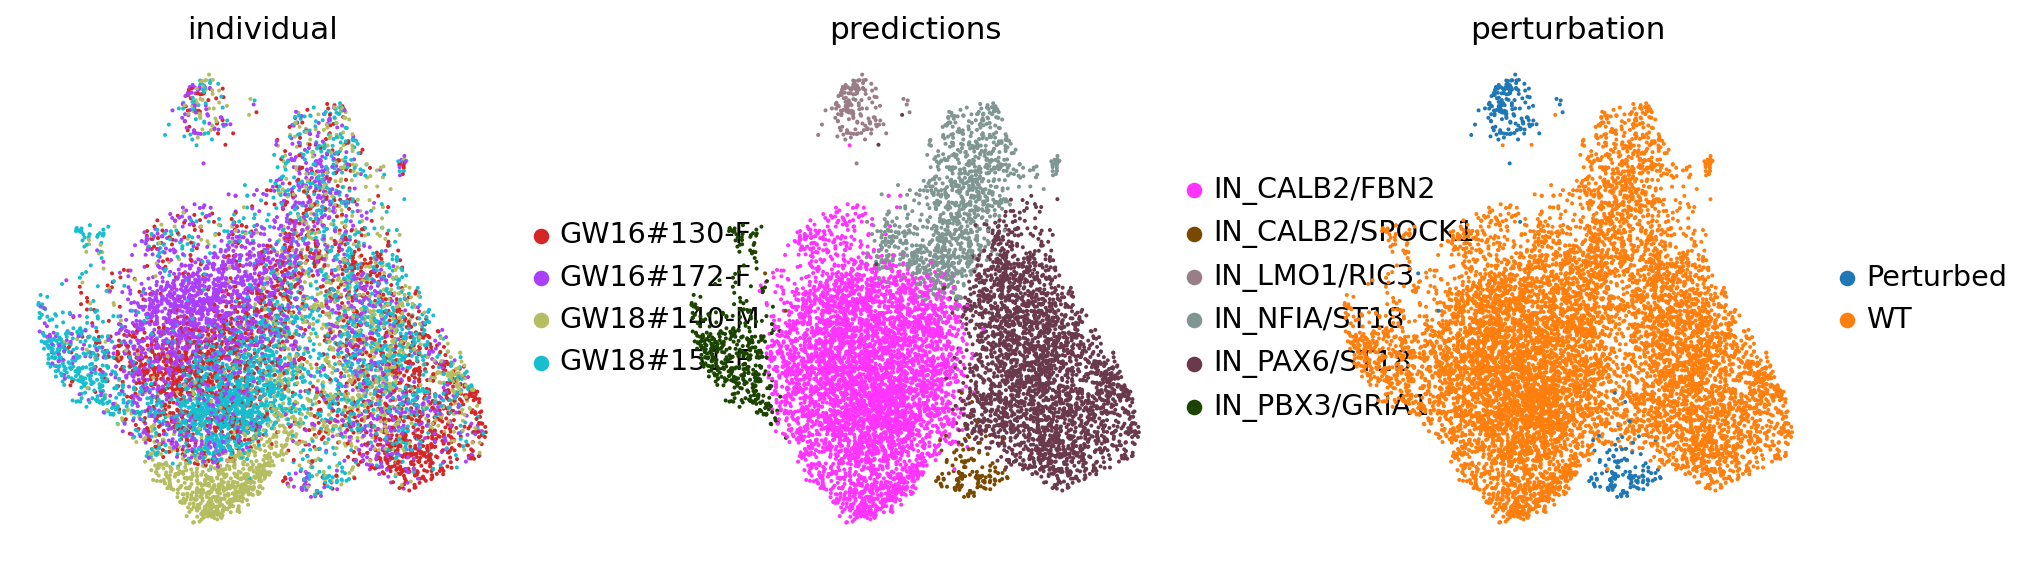

In [24]:
# Identify highly variable genes
sc.pp.highly_variable_genes(adata, batch_key='individual',min_mean=0.0125, max_mean=3, min_disp=0.5)
sc.pp.scale(adata, max_value=10)
sc.tl.pca(adata, svd_solver='arpack', use_highly_variable=True)

# Visualize
sc.pl.umap(adata, color=['individual','predictions','perturbation'], frameon=False)

/wynton/home/pollenlab/jding/miniconda3/envs/pertpy/lib/python3.9/site-packages/scanpy/plotting/_tools/scatterplots.py:394: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(
/wynton/home/pollenlab/jding/miniconda3/envs/pertpy/lib/python3.9/site-packages/scanpy/plotting/_tools/scatterplots.py:394: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(
/wynton/home/pollenlab/jding/miniconda3/envs/pertpy/lib/python3.9/site-packages/scanpy/plotting/_tools/scatterplots.py:394: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(


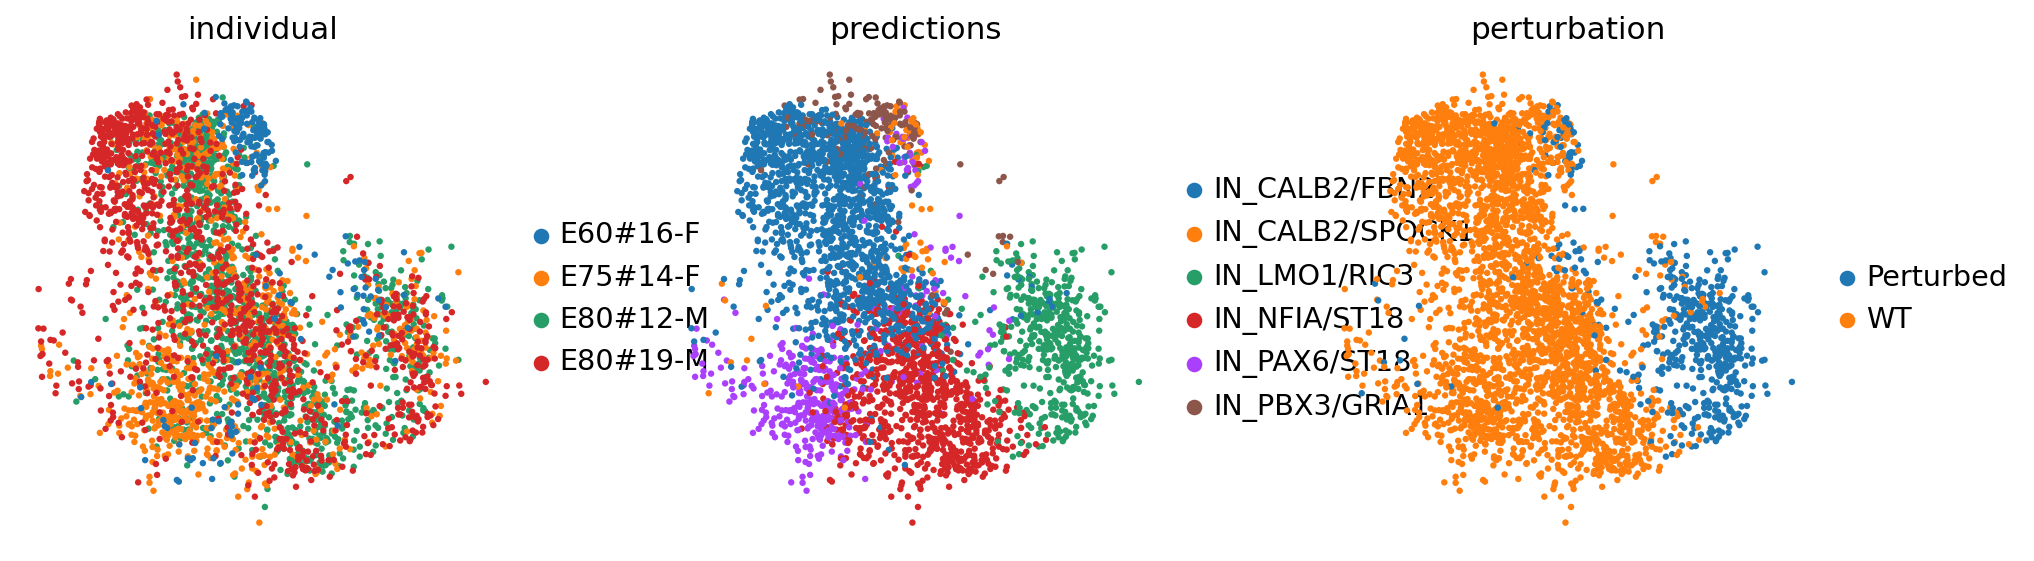

In [25]:
# Identify highly variable genes
sc.pp.highly_variable_genes(adata, batch_key='individual',min_mean=0.0125, max_mean=3, min_disp=0.5)
sc.pp.scale(adata, max_value=10)
sc.tl.pca(adata, svd_solver='arpack', use_highly_variable=True)

# Visualize
sc.pl.umap(adata, color=['individual','predictions','perturbation'], frameon=False)

/wynton/home/pollenlab/jding/miniconda3/envs/pertpy/lib/python3.9/site-packages/scanpy/plotting/_tools/scatterplots.py:394: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(
/wynton/home/pollenlab/jding/miniconda3/envs/pertpy/lib/python3.9/site-packages/scanpy/plotting/_tools/scatterplots.py:394: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(
/wynton/home/pollenlab/jding/miniconda3/envs/pertpy/lib/python3.9/site-packages/scanpy/plotting/_tools/scatterplots.py:394: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(


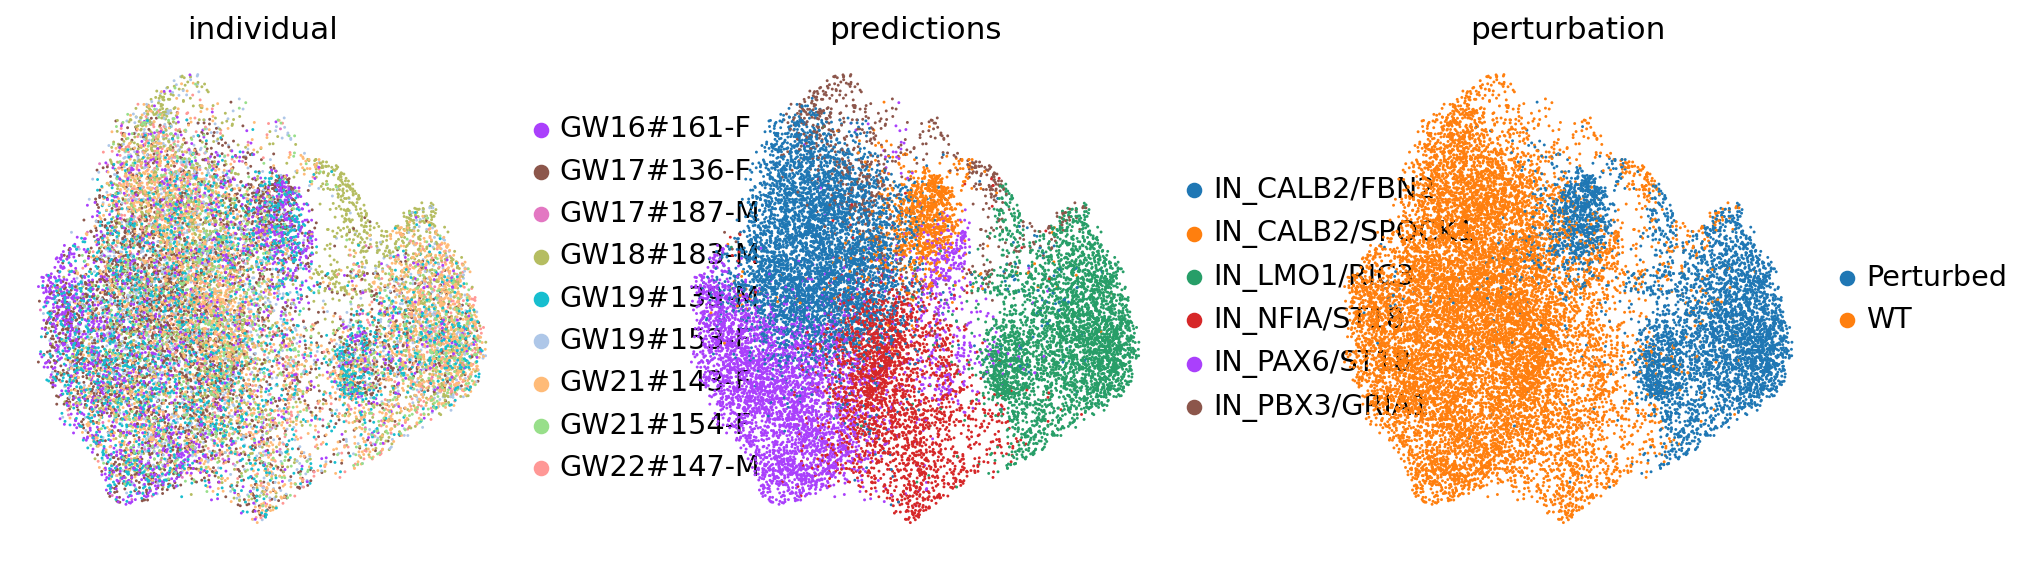

In [5]:
# Identify highly variable genes
sc.pp.highly_variable_genes(adata, batch_key='individual',min_mean=0.0125, max_mean=3, min_disp=0.5)
sc.pp.scale(adata, max_value=10)
sc.tl.pca(adata, svd_solver='arpack', use_highly_variable=True)

# Visualize
sc.pl.umap(adata, color=['individual','predictions','perturbation'], frameon=False)

/wynton/home/pollenlab/jding/miniconda3/envs/pertpy/lib/python3.9/site-packages/scanpy/plotting/_tools/scatterplots.py:394: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(


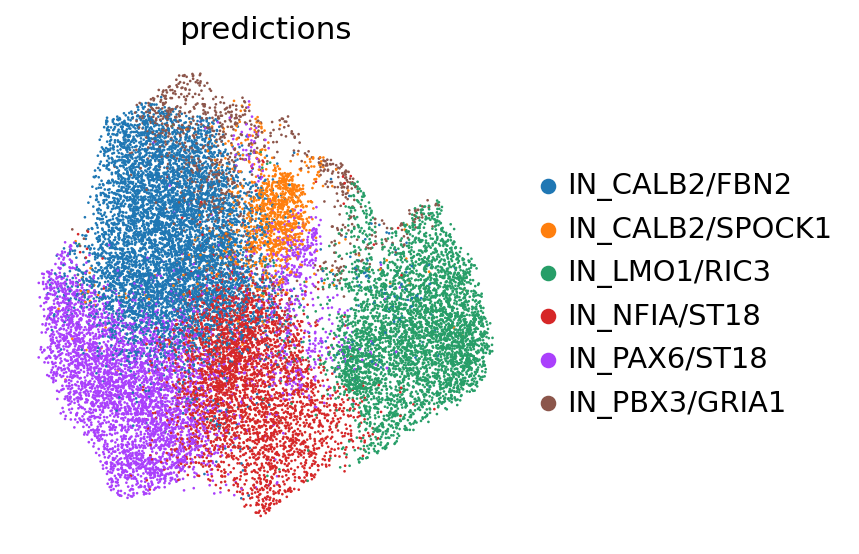

In [44]:
sc.pl.umap(adata, color=['predictions'], 
           frameon=False, legend_fontsize=13, legend_fontoutline=3,save='subtype_HM2D')

## Generation of pseudo-bulk profiles

In [92]:
# Get pseudo-bulk profile
pdata = dc.get_pseudobulk(
    adata,
    sample_col='individual',
    groups_col='predictions',
    layer='counts',
    mode='sum',
    min_cells=2,
    min_counts=0
)

It has generated a profile for each sample and cell type. We can plot their quality control metrics:

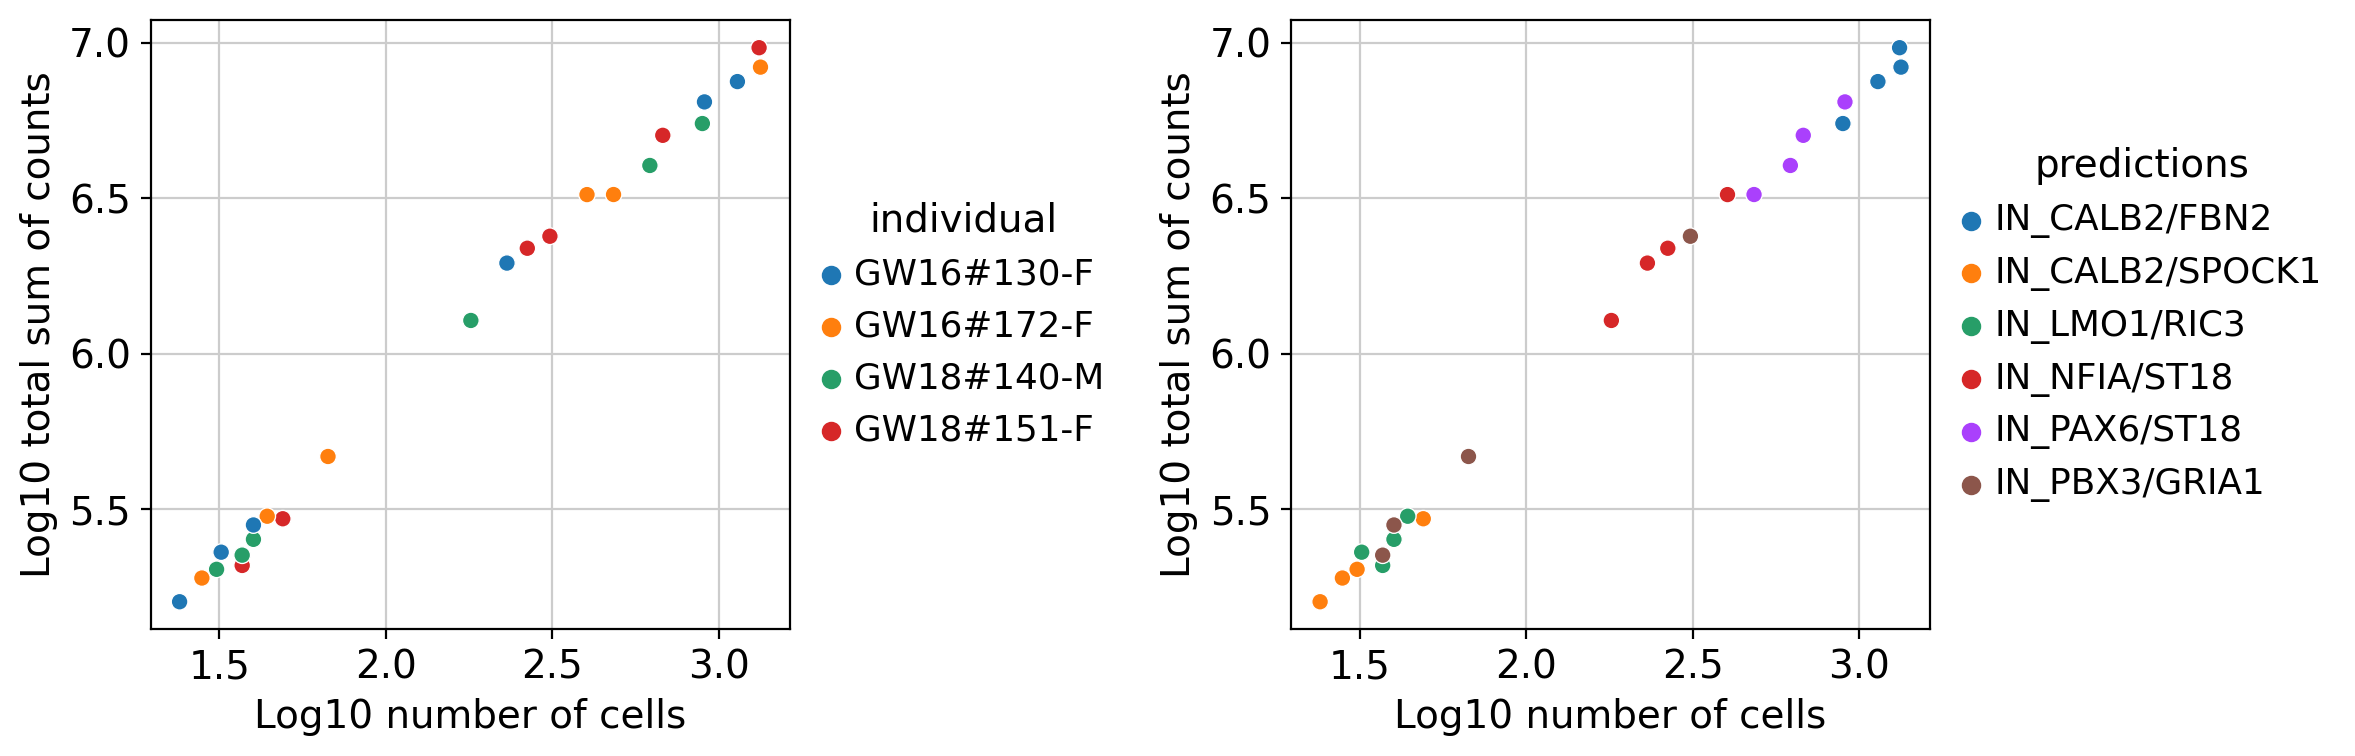

In [26]:
dc.plot_psbulk_samples(pdata, groupby=['individual', 'predictions'], figsize=(12, 4))

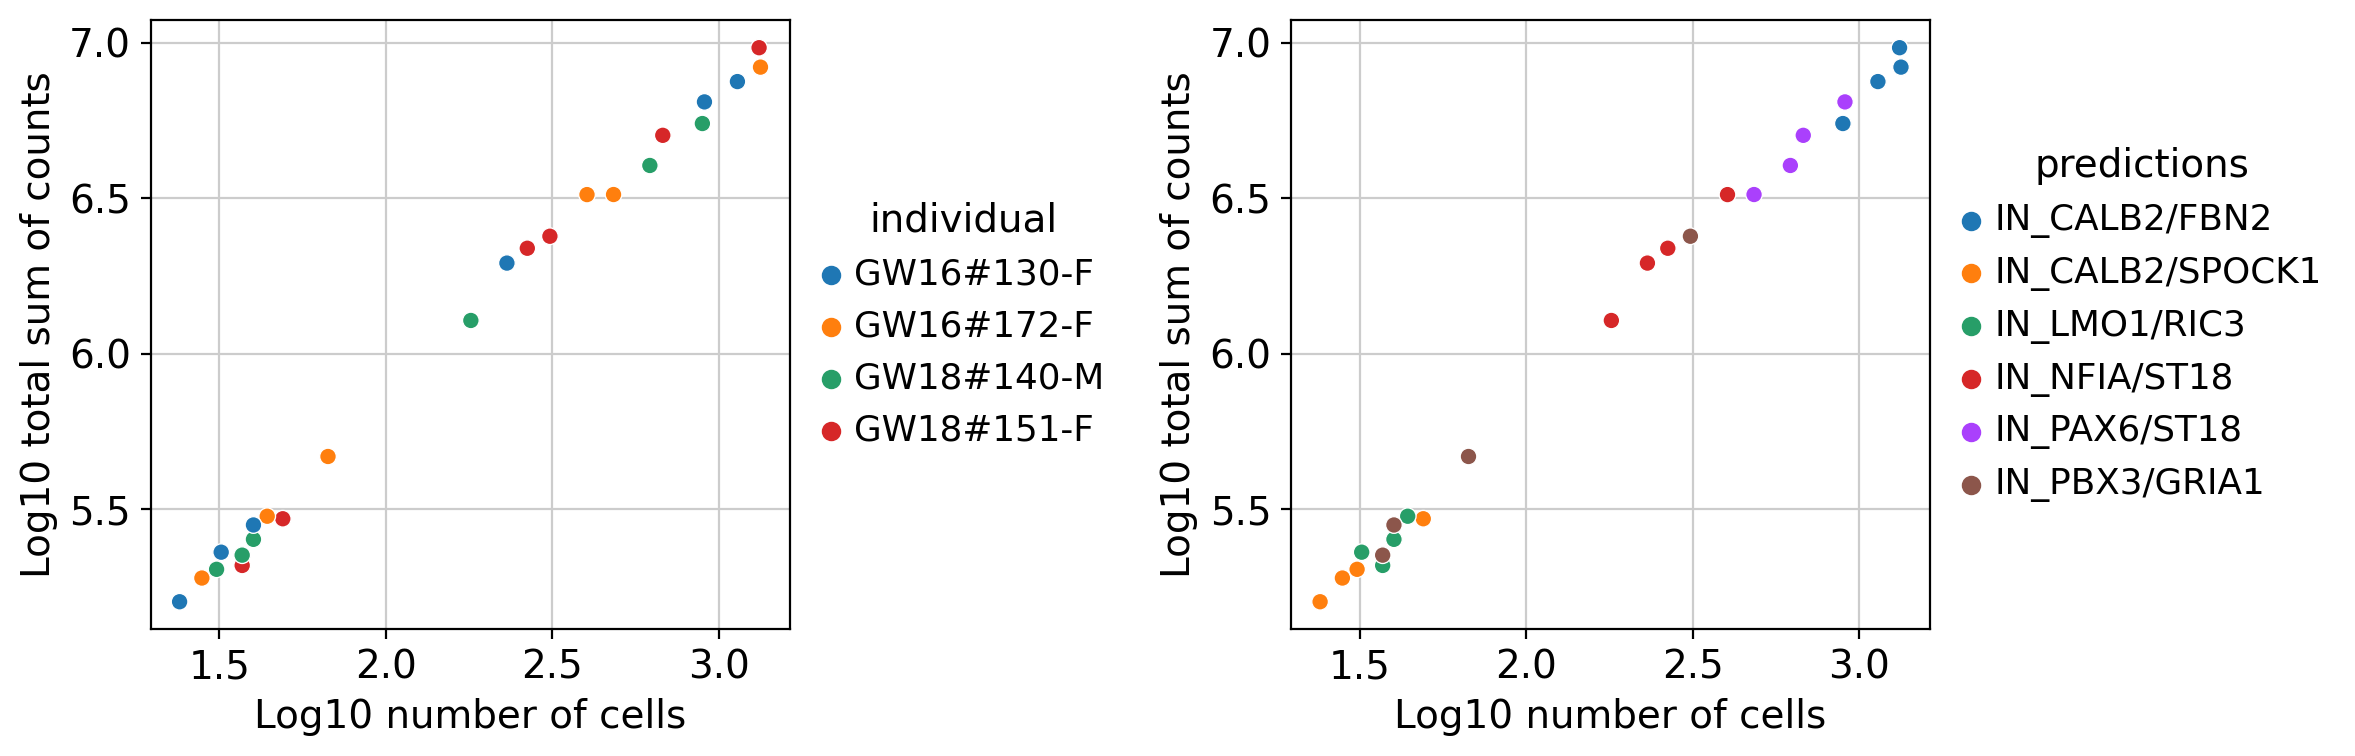

In [26]:
dc.plot_psbulk_samples(pdata, groupby=['individual', 'predictions'], figsize=(12, 4))

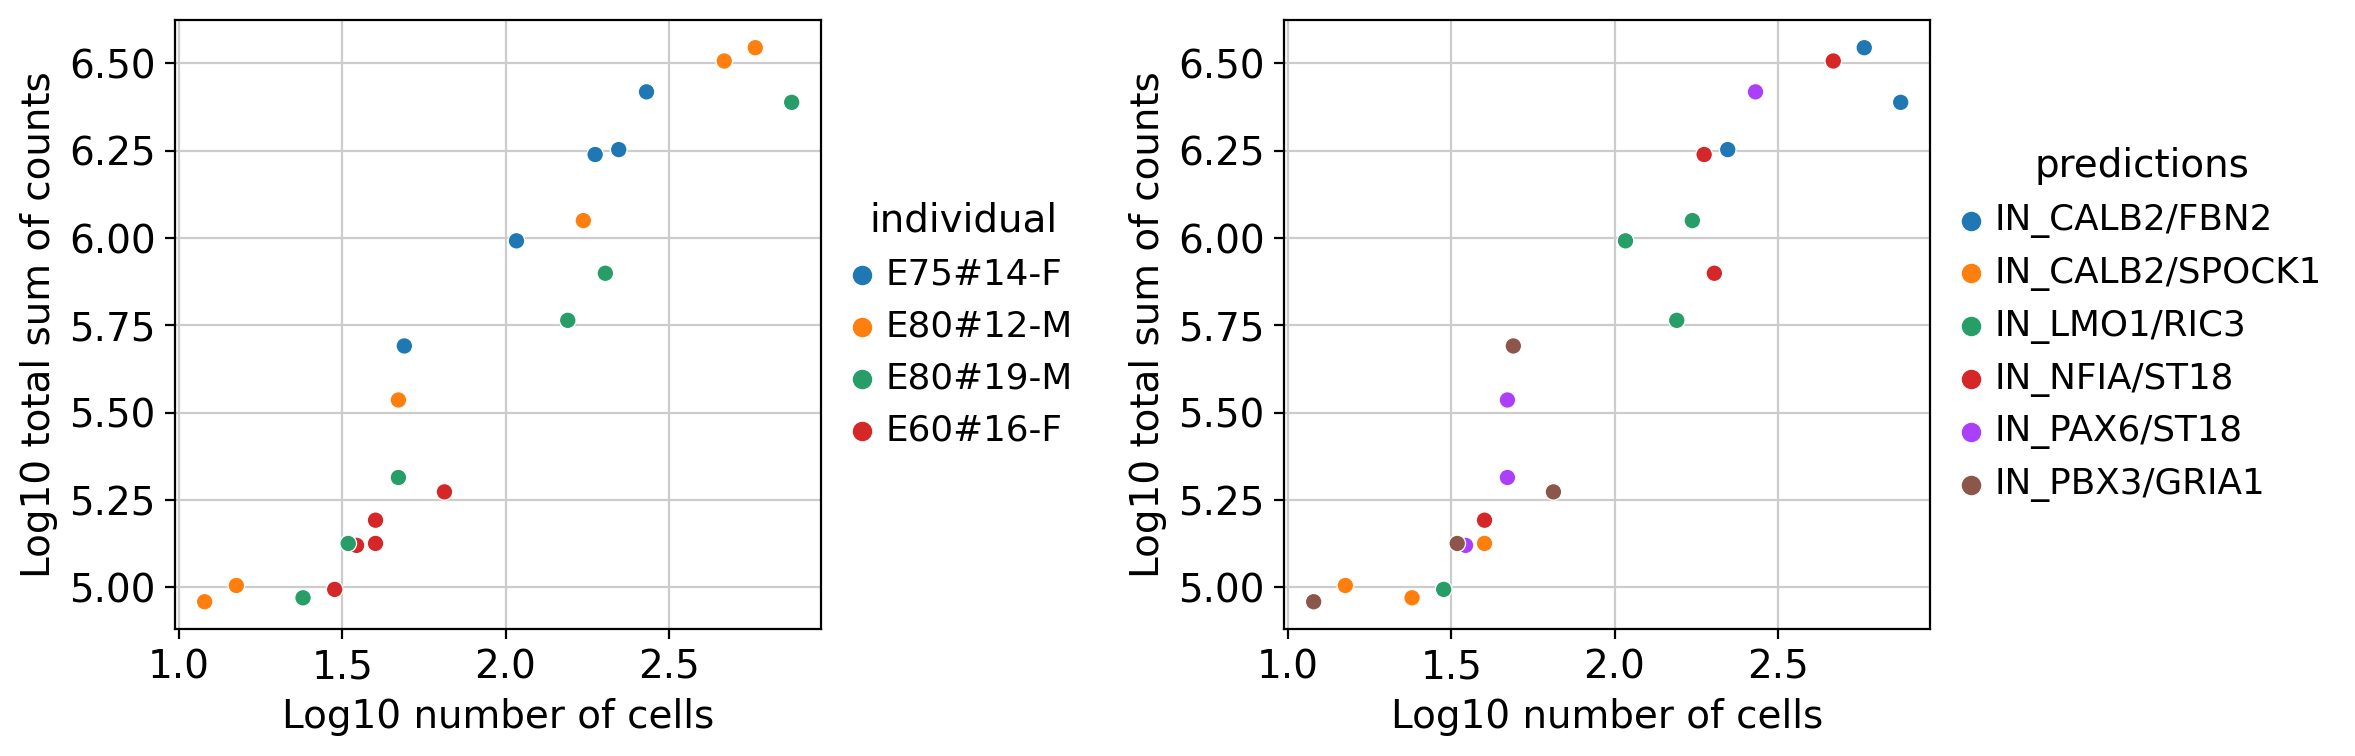

In [27]:
dc.plot_psbulk_samples(pdata, groupby=['individual', 'predictions'], figsize=(12, 4))

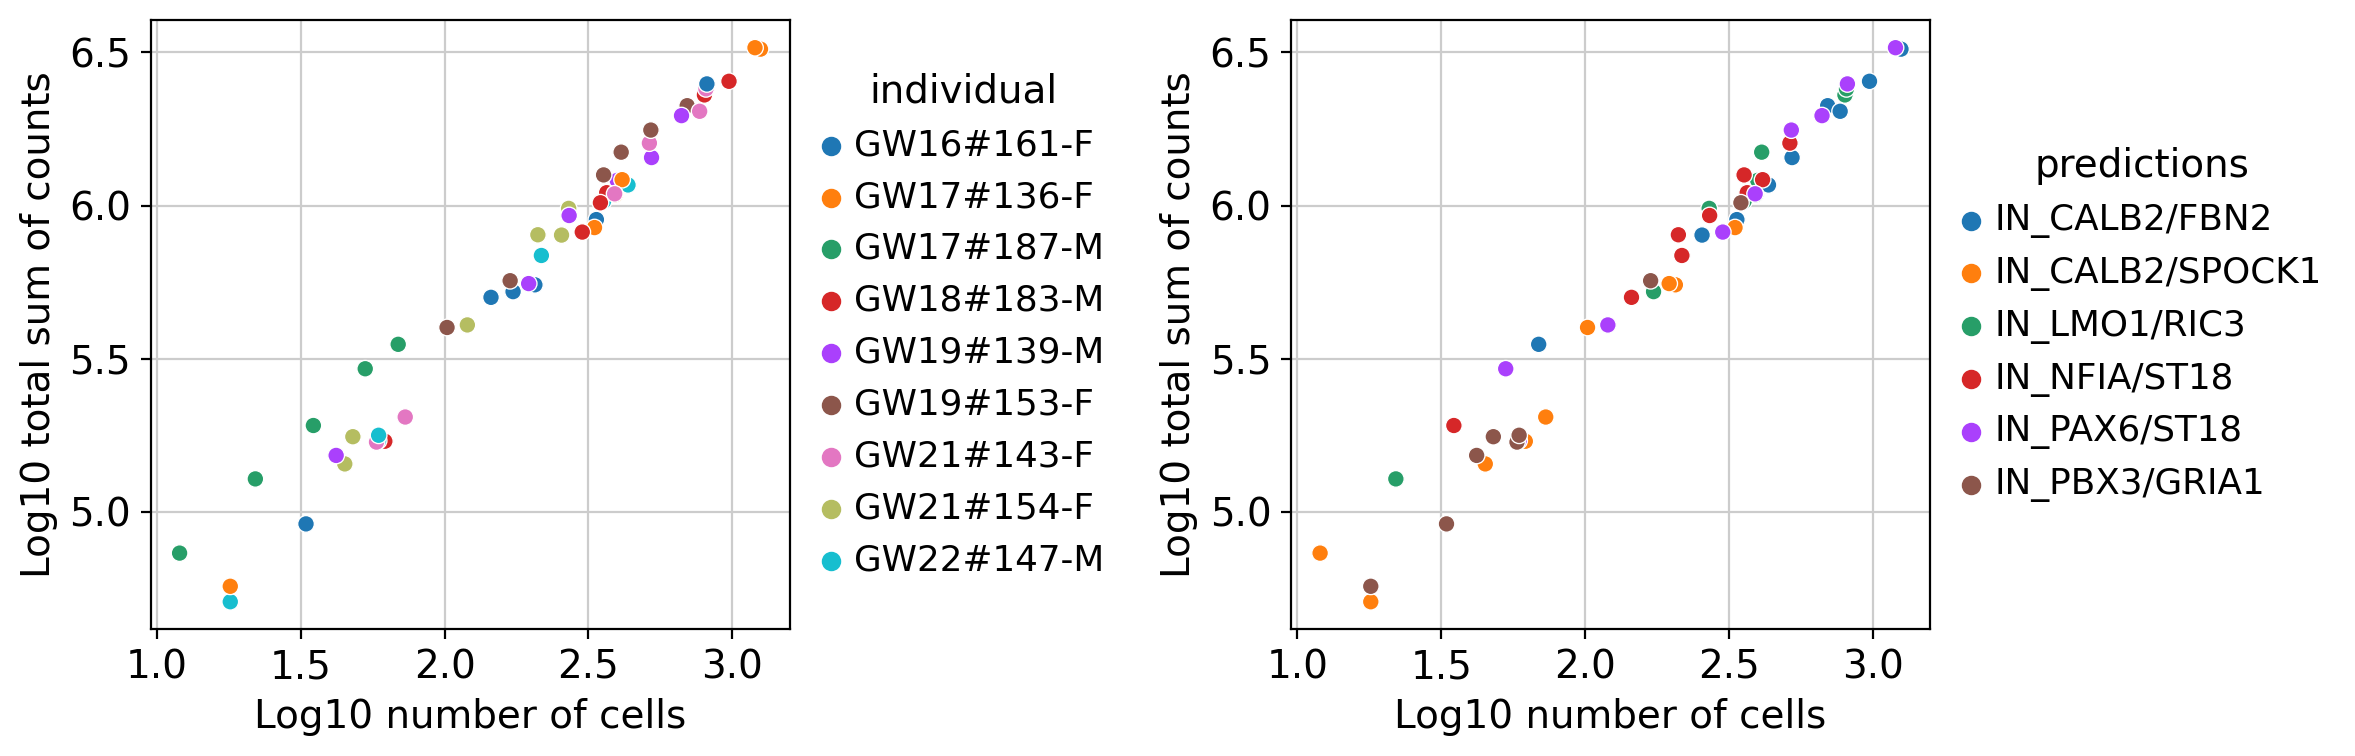

In [8]:
dc.plot_psbulk_samples(pdata, groupby=['individual', 'predictions'], figsize=(12, 4))

### Exploration of pseudobulk profiles
Now that we have generated the pseudobulk profiles for each patient and each cell type, let's explore the variability between them. For that, we will first do some simple preprocessing and then do a PCA

In [94]:
# Store raw counts in layers
pdata.layers['counts'] = pdata.X.copy()

# Normalize, scale and compute pca
sc.pp.normalize_total(pdata, target_sum=1e4)
sc.pp.log1p(pdata)
sc.pp.scale(pdata, max_value=10)
sc.tl.pca(pdata)

# Return raw counts to X
dc.swap_layer(pdata, 'counts', X_layer_key=None, inplace=True)

/wynton/home/pollenlab/jding/miniconda3/envs/pertpy/lib/python3.9/site-packages/scanpy/plotting/_tools/scatterplots.py:394: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(
/wynton/home/pollenlab/jding/miniconda3/envs/pertpy/lib/python3.9/site-packages/scanpy/plotting/_tools/scatterplots.py:394: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(


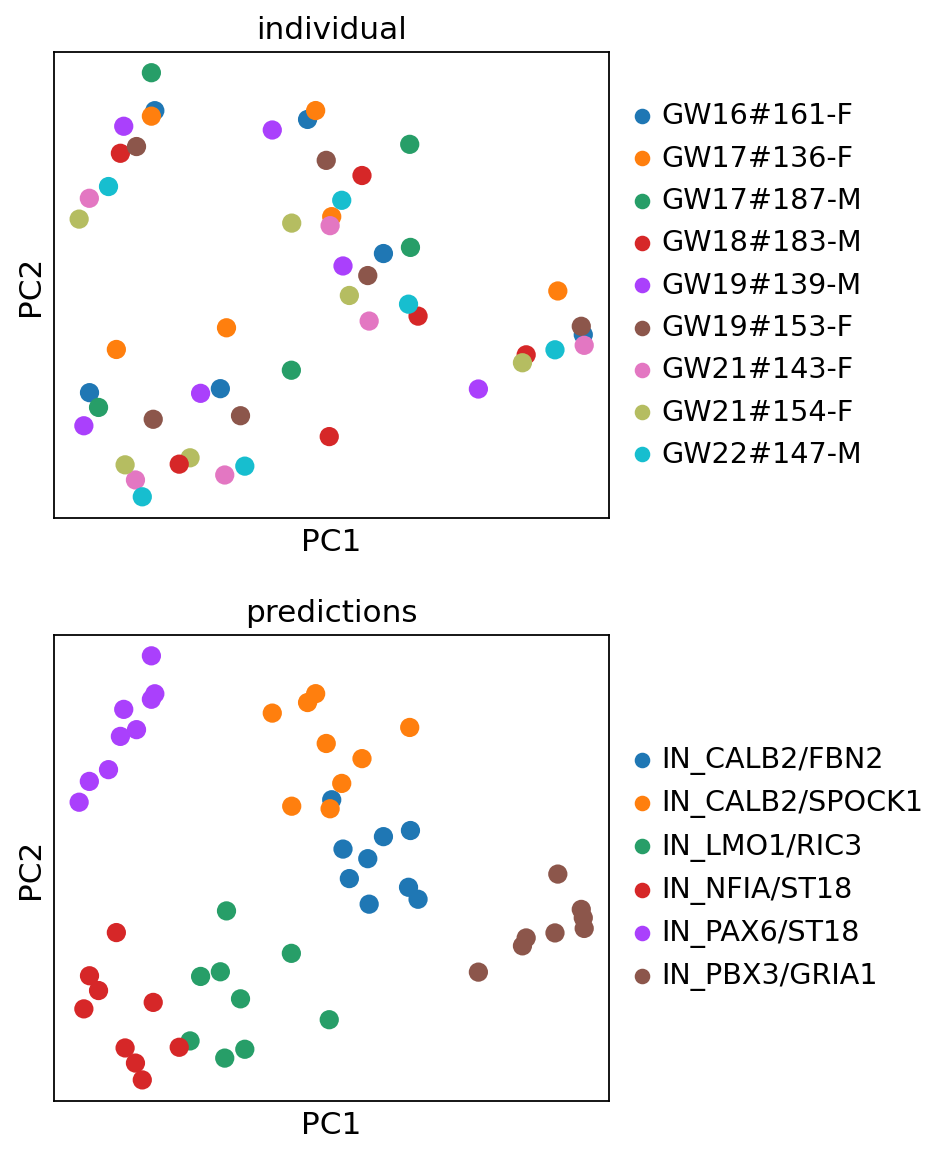

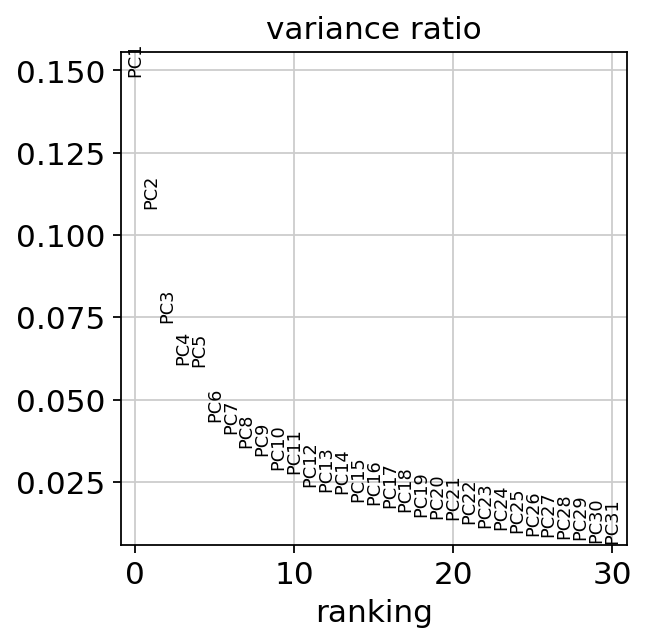

In [10]:
sc.pl.pca(pdata, color=['individual', 'predictions'], ncols=1, size=300)
sc.pl.pca_variance_ratio(pdata)

/wynton/home/pollenlab/jding/miniconda3/envs/pertpy/lib/python3.9/site-packages/scanpy/plotting/_tools/scatterplots.py:394: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(
/wynton/home/pollenlab/jding/miniconda3/envs/pertpy/lib/python3.9/site-packages/scanpy/plotting/_tools/scatterplots.py:394: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(


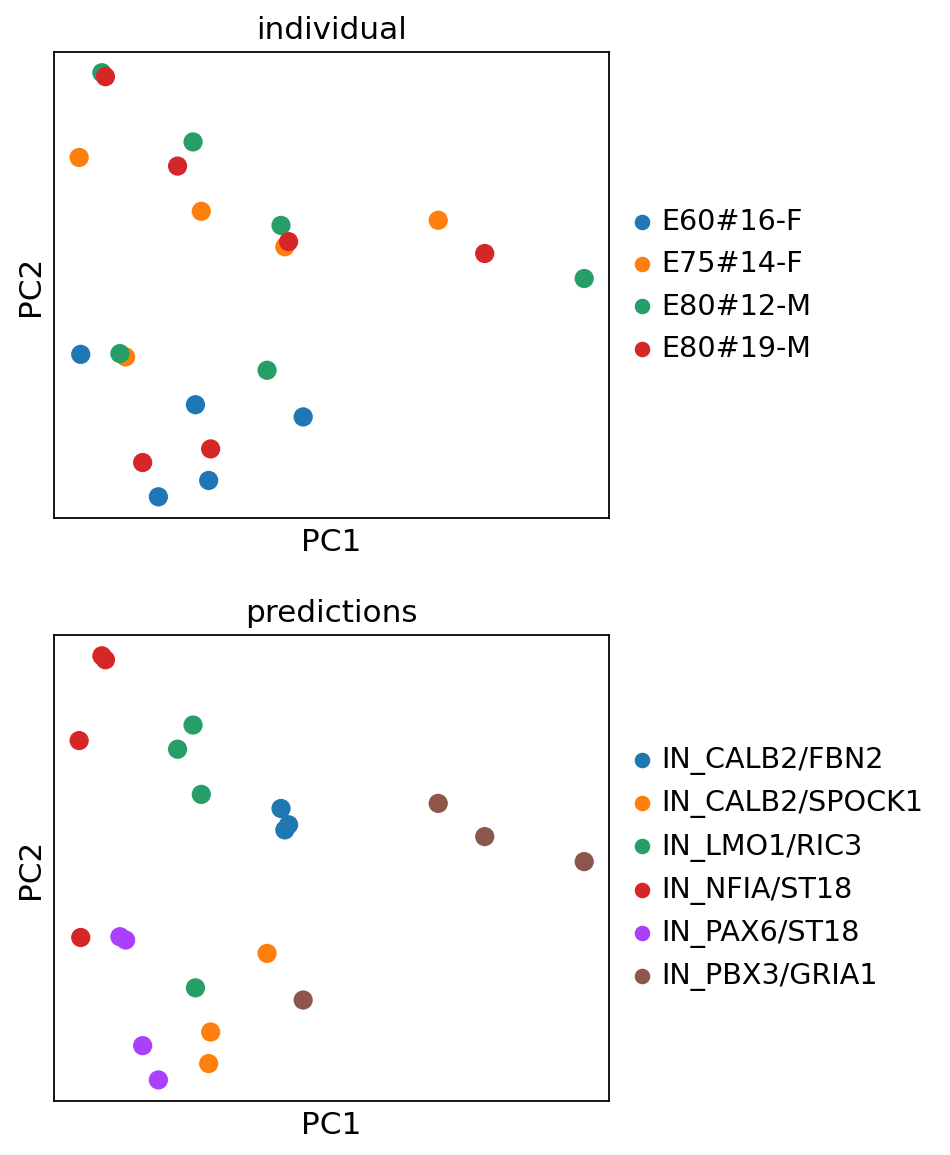

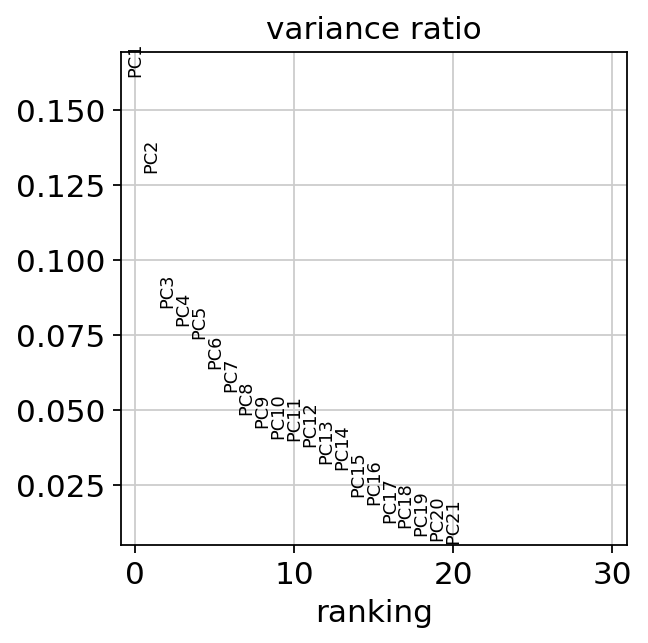

In [29]:
sc.pl.pca(pdata, color=['individual', 'predictions'], ncols=1, size=300)
sc.pl.pca_variance_ratio(pdata)

/wynton/home/pollenlab/jding/miniconda3/envs/pertpy/lib/python3.9/site-packages/scanpy/plotting/_tools/scatterplots.py:394: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(
/wynton/home/pollenlab/jding/miniconda3/envs/pertpy/lib/python3.9/site-packages/scanpy/plotting/_tools/scatterplots.py:394: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(


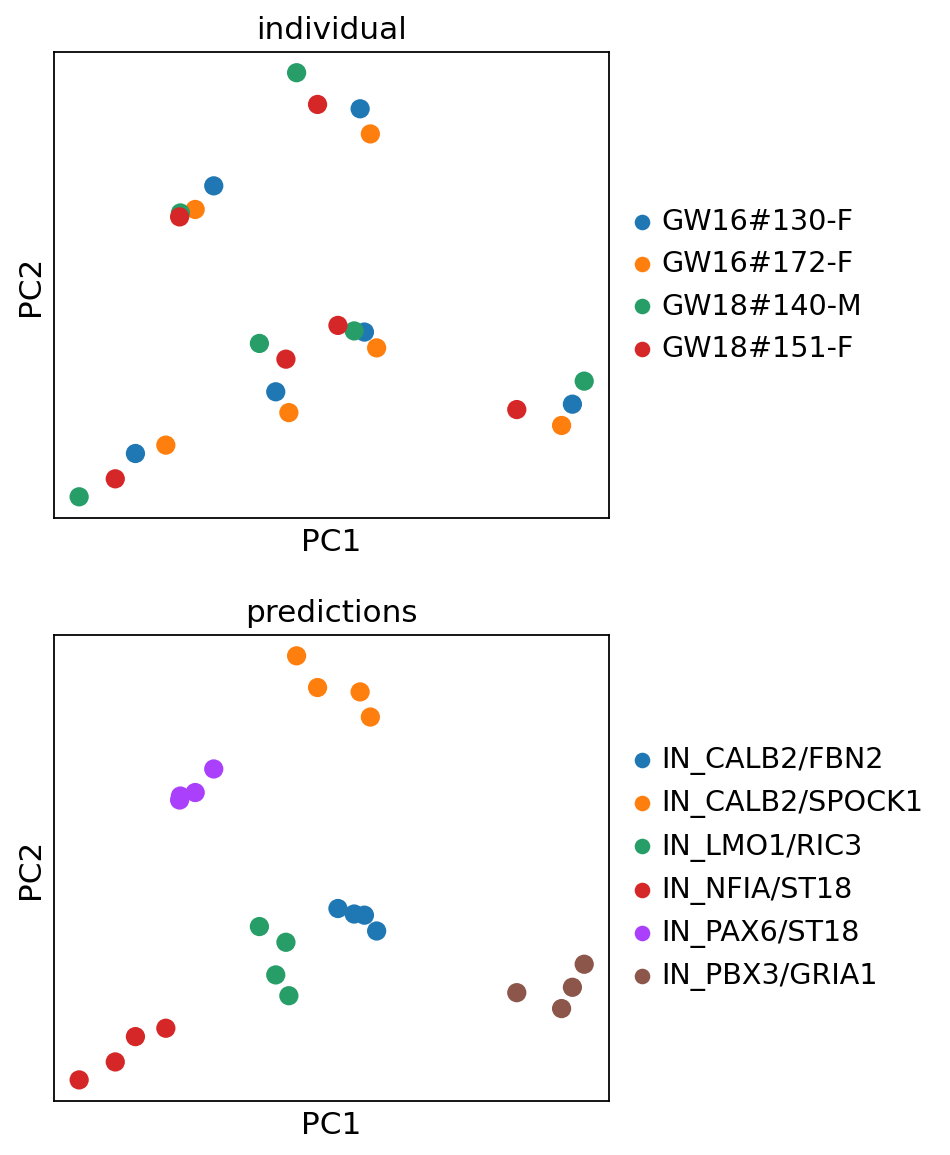

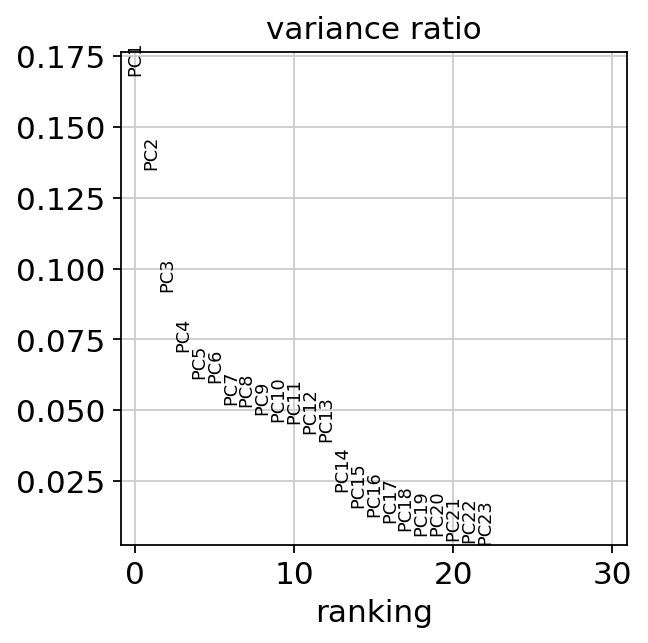

In [28]:
sc.pl.pca(pdata, color=['individual', 'predictions'], ncols=1, size=300)
sc.pl.pca_variance_ratio(pdata)

When looking at the PCA, it seems like the two first components explain most of the variance and they easily separate cell types from one another. In contrast, the principle components do not seem to be associated with disease status as such.

In order to have a better overview of the association of PCs with sample metadata, let's perform ANOVA on each PC and see whether they are significantly associated with any technical or biological annotations of our samples

In [15]:
pdata

AnnData object with n_obs × n_vars = 24 × 31557
    obs: 'GRCh38', 'rheMac10', 'call', 'species', 'individual-Q', 'individual', 'clone_barcode', 'clone_barcode_criteria', 'batch', 'timepoint', 'stage', 'sample_id', 'sex', 'species_batch', '_scvi_labels', 'labels_scanvi', 'predictions', 'class', 'leiden-.4', 'supervised_name', 'subtype', 'psbulk_n_cells', 'psbulk_counts'
    var: 'gene_ids-HD0', 'feature_types-HD0', 'genome-HD0', 'mt-HD0', 'n_cells_by_counts-HD0', 'mean_counts-HD0', 'pct_dropout_by_counts-HD0', 'total_counts-HD0', 'gene_ids-HD7', 'feature_types-HD7', 'genome-HD7', 'mt-HD7', 'n_cells_by_counts-HD7', 'mean_counts-HD7', 'pct_dropout_by_counts-HD7', 'total_counts-HD7', 'gene_ids-HM2ndD7', 'feature_types-HM2ndD7', 'genome-HM2ndD7', 'mt-HM2ndD7', 'n_cells_by_counts-HM2ndD7', 'mean_counts-HM2ndD7', 'pct_dropout_by_counts-HM2ndD7', 'total_counts-HM2ndD7', 'feature_types-HMD7', 'mt-HMD7', 'n_cells_by_counts-HMD7', 'mean_counts-HMD7', 'pct_dropout_by_counts-HMD7', 'total_counts-H

In [18]:
dc.get_metadata_associations(
    pdata,
    obs_keys = ['sex',  'predictions', 'psbulk_n_cells', 'psbulk_counts'],  # Metadata columns to associate to PCs
    obsm_key='X_pca',  # Where the PCs are stored
    uns_key='pca_anova',  # Where the results are stored
    inplace=True,
)

100%|███████████████████████████████████████████| 29/29 [00:00<00:00, 37.73it/s]


In [19]:
dc.plot_associations(
    pdata,
    uns_key='pca_anova',  # Summary statistics from the anova tests
    obsm_key='X_pca',  # where the PCs are stored
    stat_col='p_adj',  # Which summary statistic to plot
    obs_annotation_cols = ['Gene_target', 'predictions'], # which sample annotations to plot
    titles=['Principle component scores', 'Adjusted p-values from ANOVA'],
    #figsize=(7, 5),
    #n_factors=10,
)

ImportError: PyComplexHeatmap is not installed. Please install it using "pip install PyComplexHeatmap"

### Pseudo-bulk profile gene filtering

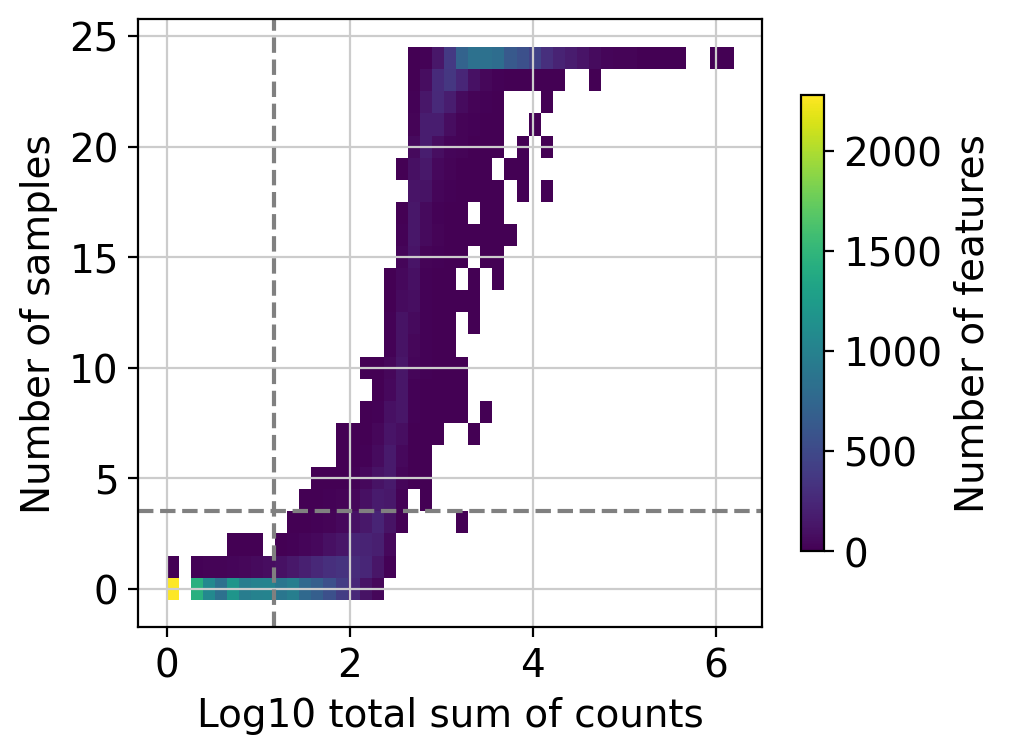

In [29]:
dc.plot_filter_by_expr(pdata, group='predictions', min_count=10, min_total_count=15)

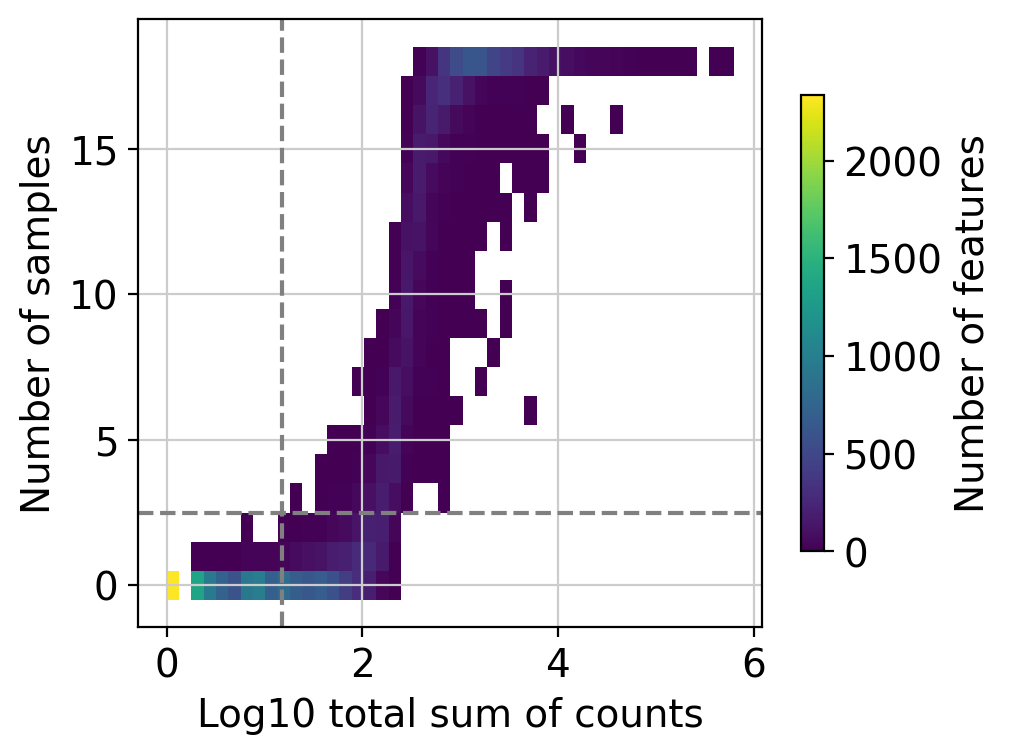

In [77]:
dc.plot_filter_by_expr(pdata, group='predictions', min_count=10, min_total_count=15)

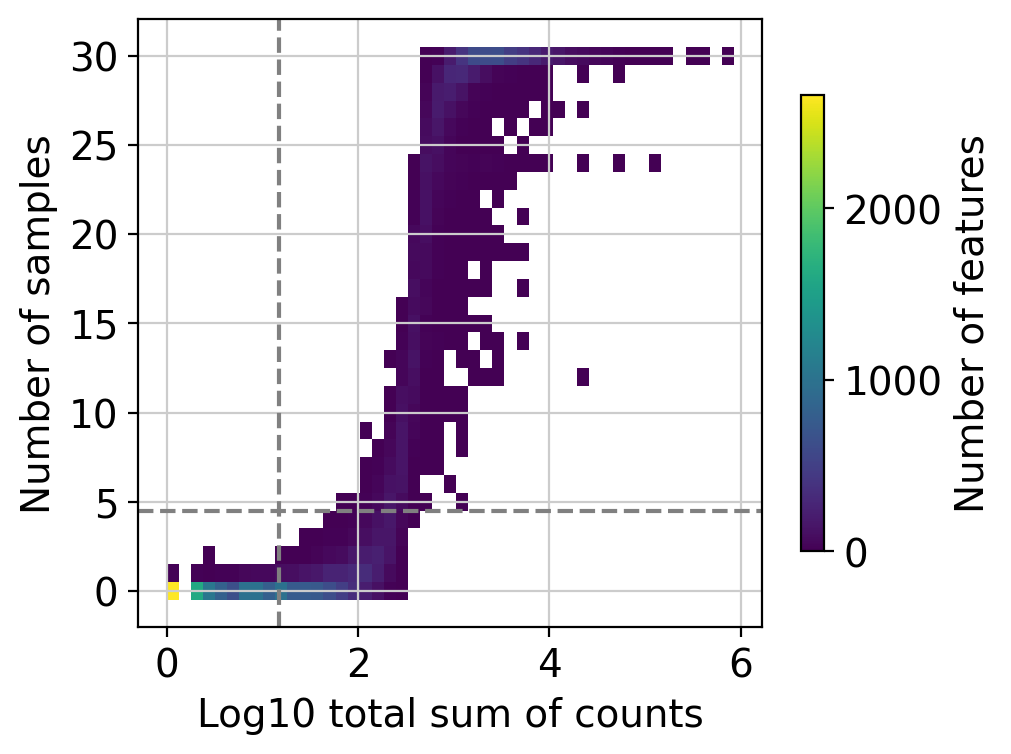

In [96]:
dc.plot_filter_by_expr(pdata, group='predictions', min_count=10, min_total_count=15)

In [30]:
# Obtain genes that pass the thresholds
genes = dc.filter_by_expr(pdata, group='predictions', min_count=10, min_total_count=15)

# Filter by these genes
pdata = pdata[:, genes].copy()
pdata

AnnData object with n_obs × n_vars = 24 × 13147
    obs: 'GRCh38', 'rheMac10', 'call', 'species', 'individual-Q', 'individual', 'clone_barcode', 'clone_barcode_criteria', 'batch', 'timepoint', 'stage', 'sample_id', 'sex', 'species_batch', '_scvi_labels', 'labels_scanvi', 'predictions', 'class', 'leiden-.4', 'supervised_name', 'subtype', 'perturbation', 'psbulk_n_cells', 'psbulk_counts'
    var: 'gene_ids-HD0', 'feature_types-HD0', 'genome-HD0', 'mt-HD0', 'n_cells_by_counts-HD0', 'mean_counts-HD0', 'pct_dropout_by_counts-HD0', 'total_counts-HD0', 'gene_ids-HD7', 'feature_types-HD7', 'genome-HD7', 'mt-HD7', 'n_cells_by_counts-HD7', 'mean_counts-HD7', 'pct_dropout_by_counts-HD7', 'total_counts-HD7', 'gene_ids-HM2ndD7', 'feature_types-HM2ndD7', 'genome-HM2ndD7', 'mt-HM2ndD7', 'n_cells_by_counts-HM2ndD7', 'mean_counts-HM2ndD7', 'pct_dropout_by_counts-HM2ndD7', 'total_counts-HM2ndD7', 'feature_types-HMD7', 'mt-HMD7', 'n_cells_by_counts-HMD7', 'mean_counts-HMD7', 'pct_dropout_by_counts-HMD7',

In [97]:
# Obtain genes that pass the thresholds
genes = dc.filter_by_expr(pdata, group='predictions', min_count=10, min_total_count=15)

# Filter by these genes
pdata = pdata[:, genes].copy()
pdata

AnnData object with n_obs × n_vars = 30 × 10914
    obs: 'species', 'individual', 'timepoint', 'stage', 'sample_id', 'sex', '_scvi_batch', '_scvi_labels', 'labels_scanvi', 'predictions', 'class', 'leiden-.4', 'supervised_name', 'perturbation', 'psbulk_n_cells', 'psbulk_counts'
    var: 'gene_ids-HD0', 'feature_types-HD0', 'genome-HD0', 'mt-HD0', 'n_cells_by_counts-HD0', 'mean_counts-HD0', 'pct_dropout_by_counts-HD0', 'total_counts-HD0', 'gene_ids-HD7', 'feature_types-HD7', 'genome-HD7', 'mt-HD7', 'n_cells_by_counts-HD7', 'mean_counts-HD7', 'pct_dropout_by_counts-HD7', 'total_counts-HD7', 'gene_ids-HM2ndD7', 'feature_types-HM2ndD7', 'genome-HM2ndD7', 'mt-HM2ndD7', 'n_cells_by_counts-HM2ndD7', 'mean_counts-HM2ndD7', 'pct_dropout_by_counts-HM2ndD7', 'total_counts-HM2ndD7', 'feature_types-HMD7', 'mt-HMD7', 'n_cells_by_counts-HMD7', 'mean_counts-HMD7', 'pct_dropout_by_counts-HMD7', 'total_counts-HMD7', 'gene_ids-0-HMD7', 'genome-0-HMD7', 'gene_ids-1-HMD7', 'genome-1-HMD7', 'highly_variable'

## Contrast between conditions

In [98]:
# Import DESeq2
from pydeseq2.dds import DeseqDataSet, DefaultInference
from pydeseq2.ds import DeseqStats

In [99]:
sub = pdata[pdata.obs['predictions'] != 'IN_CALB2/SPOCK1']
# Build DESeq2 object
inference = DefaultInference(n_cpus=1)

In [101]:
dds = DeseqDataSet(
    adata= sub,
    design_factors='perturbation',
    ref_level=['perturbation', 'WT'],
    refit_cooks=True,
    inference=inference,
)

In [102]:
# Compute LFCs
dds.deseq2()

Fitting size factors...
... done in 0.01 seconds.

Fitting dispersions...
... done in 10.08 seconds.

Fitting dispersion trend curve...
... done in 0.46 seconds.

Fitting MAP dispersions...
... done in 11.65 seconds.

Fitting LFCs...
... done in 5.40 seconds.

Calculating cook's distance...
... done in 0.02 seconds.

Replacing 10 outlier genes.

Fitting dispersions...
... done in 0.01 seconds.

Fitting MAP dispersions...
... done in 0.01 seconds.

Fitting LFCs...
... done in 0.01 seconds.



In [103]:
# Extract contrast between COVID-19 vs normal
stat_res = DeseqStats(
    dds,
    contrast=["perturbation", 'Perturbed', 'WT'],
    inference=inference,
)

In [104]:
# Compute Wald test
stat_res.summary()

Running Wald tests...


Log2 fold change & Wald test p-value: perturbation Perturbed vs WT
            baseMean  log2FoldChange     lfcSE      stat    pvalue      padj
A1BG        8.220782       -0.246347  0.325206 -0.757511  0.448744  0.932500
A2M        14.261259        0.015261  0.195571  0.078033  0.937802  0.997567
A2ML1-AS1  14.411122        0.065267  0.275805  0.236643  0.812934  0.992849
AAAS        8.235639       -0.372052  0.275122 -1.352317  0.176274  0.751598
AACS       30.341889       -0.173353  0.176914 -0.979872  0.327149  0.877261
...              ...             ...       ...       ...       ...       ...
ZWILCH      8.432425       -0.668148  0.265522 -2.516361  0.011857  0.189423
ZXDC       56.324315       -0.004137  0.149133 -0.027738  0.977871  0.997811
ZYG11B     93.343791       -0.170980  0.123631 -1.382990  0.166668  0.734769
ZZEF1      48.640473       -0.029677  0.154236 -0.192411  0.847420  0.995589
ZZZ3       80.309823        0.034957  0.104850  0.333403  0.738830  0.980893

[10914 r

... done in 1.12 seconds.



In [105]:
# Extract results
results_df = stat_res.results_df
results_df

,baseMean,log2FoldChange,lfcSE,stat,pvalue,padj
A1BG,8.220782,-0.246347,0.325206,-0.757511,0.448744,0.932500
A2M,14.261259,0.015261,0.195571,0.078033,0.937802,0.997567
A2ML1-AS1,14.411122,0.065267,0.275805,0.236643,0.812934,0.992849
AAAS,8.235639,-0.372052,0.275122,-1.352317,0.176274,0.751598
AACS,30.341889,-0.173353,0.176914,-0.979872,0.327149,0.877261
...,...,...,...,...,...,...
ZWILCH,8.432425,-0.668148,0.265522,-2.516361,0.011857,0.189423
ZXDC,56.324315,-0.004137,0.149133,-0.027738,0.977871,0.997811
ZYG11B,93.343791,-0.170980,0.123631,-1.382990,0.166668,0.734769
ZZEF1,48.640473,-0.029677,0.154236,-0.192411,0.847420,0.995589


In [67]:
dir='/wynton/group/pollen/jding/brainchromatin/HM2D/DEseq2/'
stat_res.results_df.to_csv(os.path.join(dir, 'IN_LMO1RIC3.csv'))

In [86]:
dir='/wynton/group/pollen/jding/brainchromatin/HM2D/DEseq2/'
stat_res.results_df.to_csv(os.path.join(dir, 'IN_LMO1RIC3_macaque.csv'))

In [106]:
dir='/wynton/group/pollen/jding/brainchromatin/HM2D/DEseq2/'
stat_res.results_df.to_csv(os.path.join(dir, 'IN_LMO1RIC3_human.csv'))

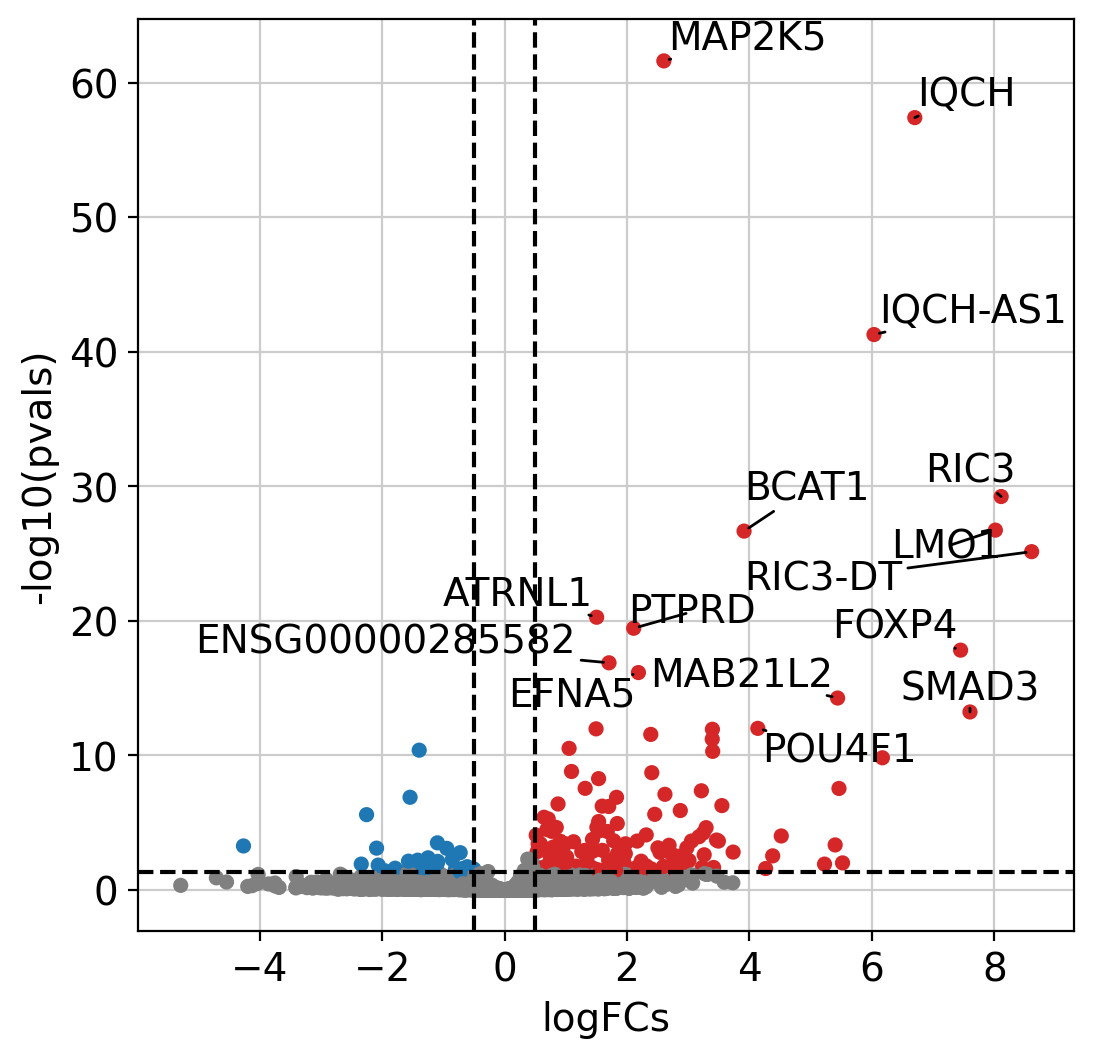

In [66]:
dc.plot_volcano_df(
    results_df,
    x='log2FoldChange', #color_pos='#f43f03', color_neg='#316dd4',
    y='padj',
    top=15,
    figsize=(6, 6),
    save=None
)

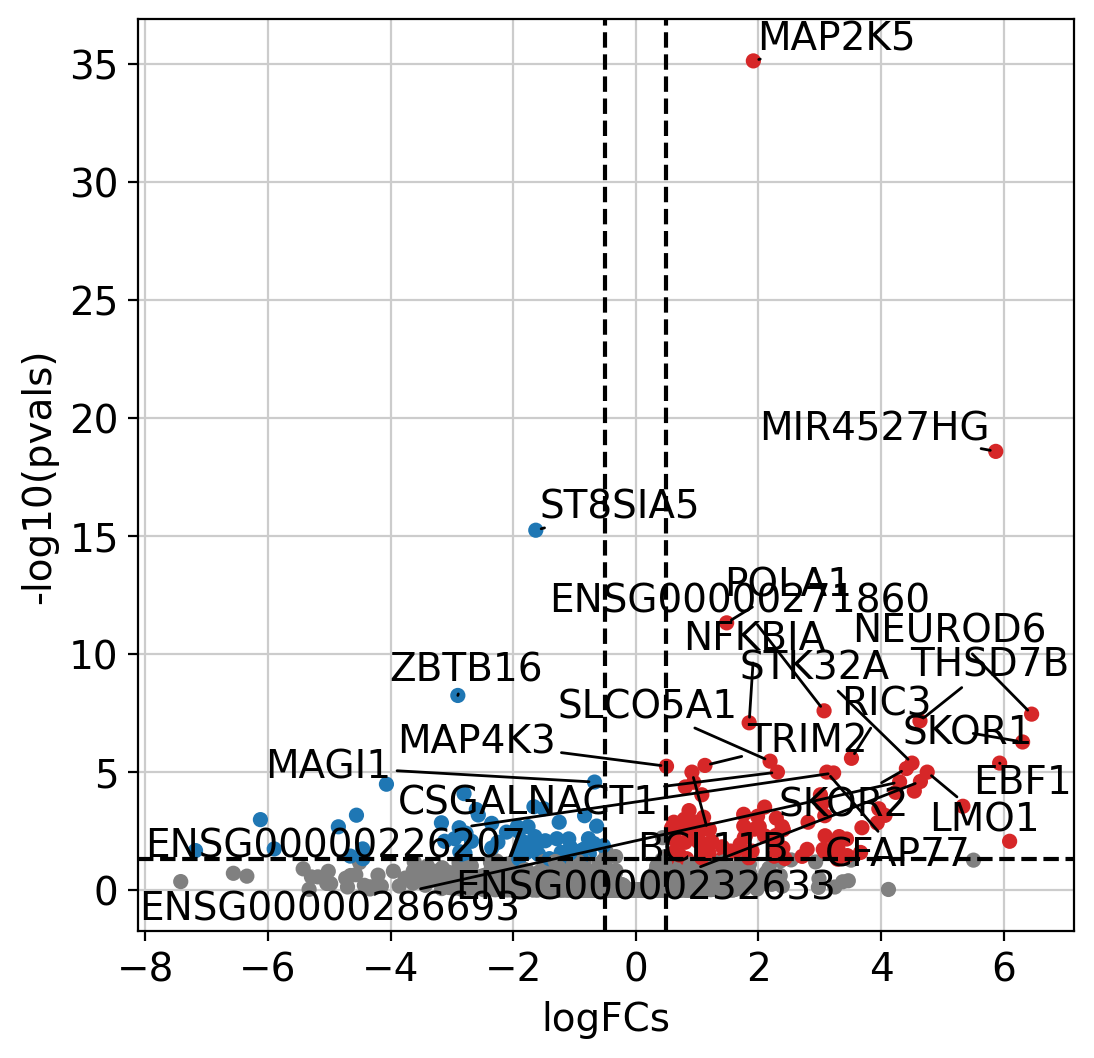

In [88]:
#macaque
dc.plot_volcano_df(
    results_df,
    x='log2FoldChange', #color_pos='#f43f03', color_neg='#316dd4',
    y='padj',
    top=25,
    figsize=(6, 6),
    save=None
)

In [108]:
mat = results_df[['stat']].T.rename(index={'stat': 'IN_LMO1/RIC3'})
mat

,A1BG,A2M,A2ML1-AS1,AAAS,AACS,AADAT,AAGAB,AAK1,AAMDC,AAMP,...,ZSWIM7,ZSWIM8,ZSWIM9,ZUP1,ZW10,ZWILCH,ZXDC,ZYG11B,ZZEF1,ZZZ3
IN_LMO1/RIC3,-0.757511,0.078033,0.236643,-1.352317,-0.979872,-0.234246,3.543001,-0.924718,-0.547136,0.848238,...,-1.008886,0.399823,0.352565,-1.105927,-0.329459,-2.516361,-0.027738,-1.38299,-0.192411,0.333403


In [131]:
dir='/wynton/group/pollen/jding/brainchromatin/HM2D/DEseq2/'
results_df = pd.read_csv(os.path.join(dir, 'IN_LMO1RIC3.csv'), index_col=0)
mat = results_df[['stat']].T.rename(index={'stat': 'IN_LMO1/RIC3'})
mat

,A1BG,A1BG-AS1,A2M,A2ML1-AS1,AAAS,AACS,AADAT,AAGAB,AAK1,AAMDC,...,ZSWIM9,ZUP1,ZW10,ZWILCH,ZXDB,ZXDC,ZYG11B,ZYX,ZZEF1,ZZZ3
IN_LMO1/RIC3,-1.582318,-0.578233,1.198438,0.610574,0.545416,-2.054769,1.099494,5.230041,0.072876,-0.943188,...,1.097685,2.583294,-0.627997,-1.376272,2.741682,0.740212,0.19793,-1.804464,-1.038884,1.595694


## Transcription factor activity inference

In [39]:
# Retrieve CollecTRI gene regulatory network
collectri = dc.get_collectri(organism='human', split_complexes=False)
collectri

0.00B [00:00, ?B/s]

0.00B [00:00, ?B/s]

,source,target,weight,PMID
0,MYC,TERT,1,10022128;10491298;10606235;10637317;10723141;1...
1,SPI1,BGLAP,1,10022617
2,SMAD3,JUN,1,10022869;12374795
3,SMAD4,JUN,1,10022869;12374795
4,STAT5A,IL2,1,10022878;11435608;17182565;17911616;22854263;2...
...,...,...,...,...
43173,NFKB,hsa-miR-143-3p,1,19472311
43174,AP1,hsa-miR-206,1,19721712
43175,NFKB,hsa-miR-21-5p,1,20813833;22387281
43176,NFKB,hsa-miR-224-5p,1,23474441;23988648


### Activity inference with Univariate Linear Model (ULM)

In [109]:
# Infer pathway activities with ulm
tf_acts, tf_pvals = dc.run_ulm(mat=mat, net=collectri)
tf_acts

,ABL1,AHR,AIRE,AP1,APEX1,AR,ARID1A,ARID3B,ARID4A,ARNT,...,ZNF331,ZNF350,ZNF354C,ZNF362,ZNF382,ZNF384,ZNF436,ZNF699,ZNF76,ZNF91
IN_LMO1/RIC3,-1.394524,-2.17994,-0.501656,-0.416367,1.696676,-0.987023,1.316572,-0.551737,-0.459907,-0.311617,...,-0.421891,0.070583,-0.675942,-3.112673,-0.503981,-0.337758,0.149275,0.764686,0.258414,0.799328


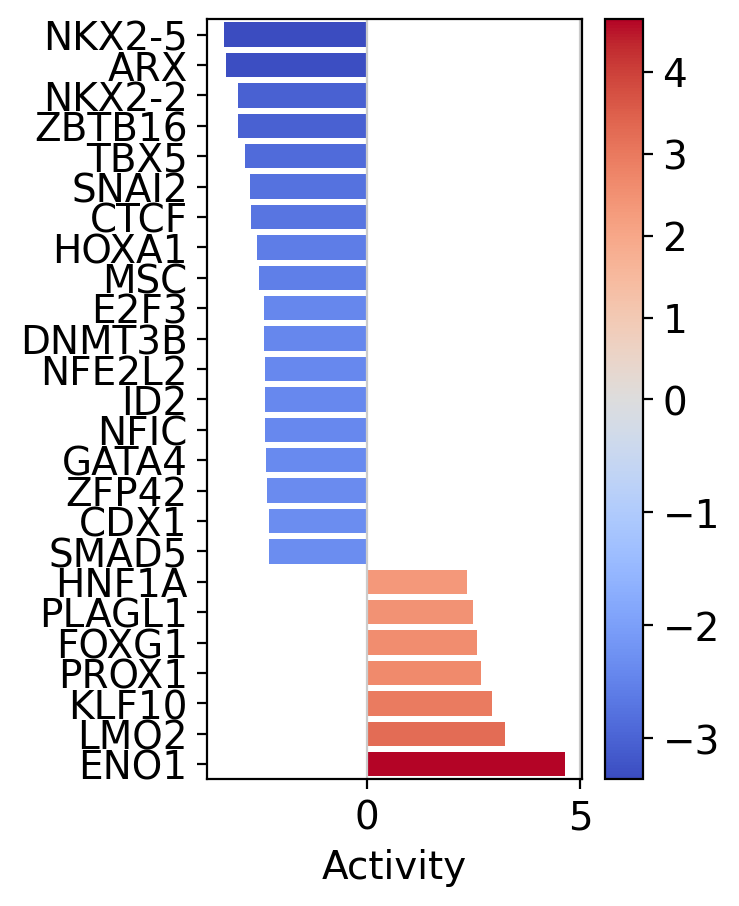

In [69]:
dc.plot_barplot(
    acts=tf_acts,
    contrast='IN_LMO1/RIC3',
    top=25,
    vertical=True,
    figsize=(3, 5)
)

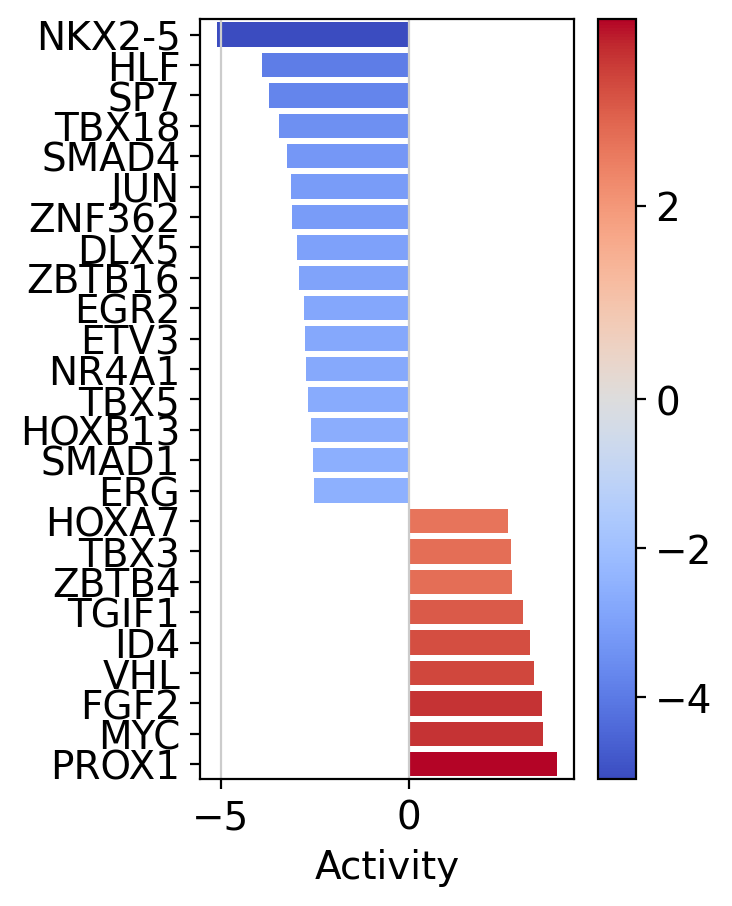

In [110]:
dc.plot_barplot(
    acts=tf_acts,
    contrast='IN_LMO1/RIC3',
    top=25,
    vertical=True,
    figsize=(3, 5)
)

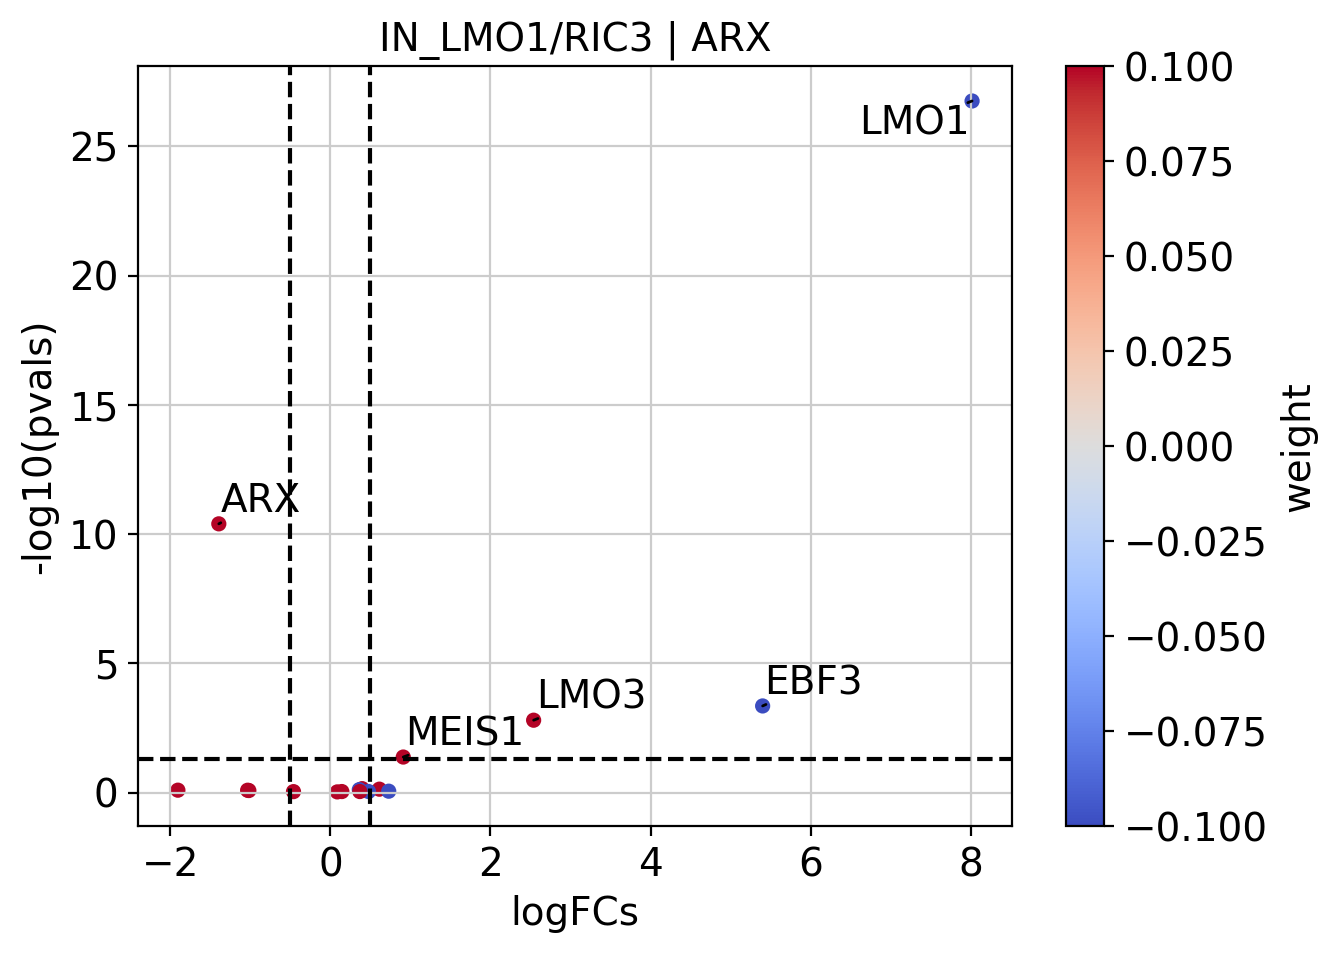

In [45]:
# Extract logFCs and pvals
logFCs = results_df[['log2FoldChange']].T.rename(index={'log2FoldChange': 'IN_LMO1/RIC3'})
pvals = results_df[['padj']].T.rename(index={'padj': 'IN_LMO1/RIC3'})

# Plot
dc.plot_volcano(
    logFCs=logFCs,
    pvals=pvals,
    contrast='IN_LMO1/RIC3',
    name='ARX',
    net=collectri,
    top=10,
    sign_thr=0.05,
    lFCs_thr=0.5
)

## Pathway activity inference

Another analysis we can perform is to infer pathway activities from our transcriptomics data.

### PROGENy model

[PROGENy](https://saezlab.github.io/progeny/) is a comprehensive resource containing a curated collection of pathways and their target genes, with weights for each interaction.
For this example we will use the human weights (other organisms are available) and we will use the top 500 responsive genes ranked by p-value. Here is a brief description of each pathway:

- **Androgen**: involved in the growth and development of the male reproductive organs.
- **EGFR**: regulates growth, survival, migration, apoptosis, proliferation, and differentiation in mammalian cells
- **Estrogen**: promotes the growth and development of the female reproductive organs.
- **Hypoxia**: promotes angiogenesis and metabolic reprogramming when O2 levels are low.
- **JAK-STAT**: involved in immunity, cell division, cell death, and tumor formation.
- **MAPK**: integrates external signals and promotes cell growth and proliferation.
- **NFkB**: regulates immune response, cytokine production and cell survival.
- **p53**: regulates cell cycle, apoptosis, DNA repair and tumor suppression.
- **PI3K**: promotes growth and proliferation.
- **TGFb**: involved in development, homeostasis, and repair of most tissues.
- **TNFa**: mediates haematopoiesis, immune surveillance, tumour regression and protection from infection.
- **Trail**: induces apoptosis.
- **VEGF**: mediates angiogenesis, vascular permeability, and cell migration.
- **WNT**: regulates organ morphogenesis during development and tissue repair.

To access it we can use `decoupler`.

In [47]:
# Retrieve PROGENy model weights
progeny = dc.get_progeny(top=500)
progeny

0.00B [00:00, ?B/s]

,source,target,weight,p_value
0,Androgen,TMPRSS2,11.490631,0.000000e+00
1,Androgen,NKX3-1,10.622551,2.242078e-44
2,Androgen,MBOAT2,10.472733,4.624285e-44
3,Androgen,KLK2,10.176186,1.944414e-40
4,Androgen,SARG,11.386852,2.790209e-40
...,...,...,...,...
6995,p53,ZMYM4,-2.325752,1.522388e-06
6996,p53,CFDP1,-1.628168,1.526045e-06
6997,p53,VPS37D,2.309503,1.537098e-06
6998,p53,TEDC1,-2.274823,1.547037e-06


### Activity inference with Multivariate Linear Model (MLM)


In [111]:
# Infer pathway activities with mlm
pathway_acts, pathway_pvals = dc.run_mlm(mat=mat, net=progeny)
pathway_acts

,Androgen,EGFR,Estrogen,Hypoxia,JAK-STAT,MAPK,NFkB,PI3K,TGFb,TNFa,Trail,VEGF,WNT,p53
IN_LMO1/RIC3,-0.737476,-0.857402,-0.968864,-1.652691,-0.245356,0.811913,0.858559,0.731186,0.402088,-1.492273,-1.834361,1.050772,0.12006,-0.713764


Let us plot the obtained scores:

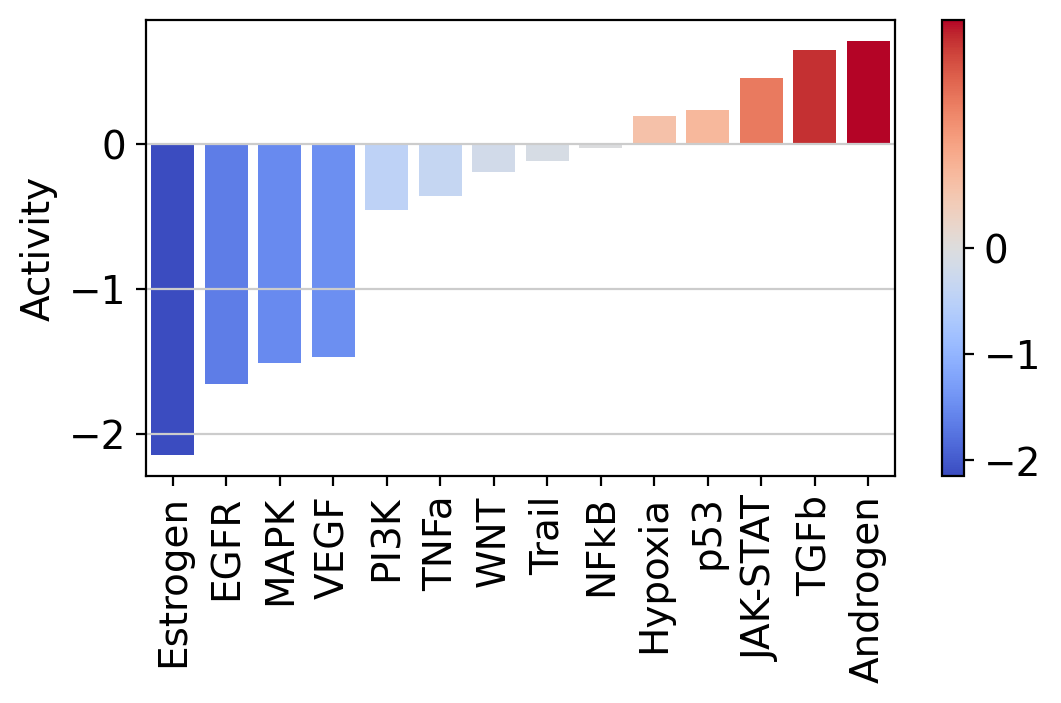

In [49]:
dc.plot_barplot(
    acts=pathway_acts,
    contrast='IN_LMO1/RIC3',
    top=25,
    vertical=True,
    figsize=(3, 6)
)

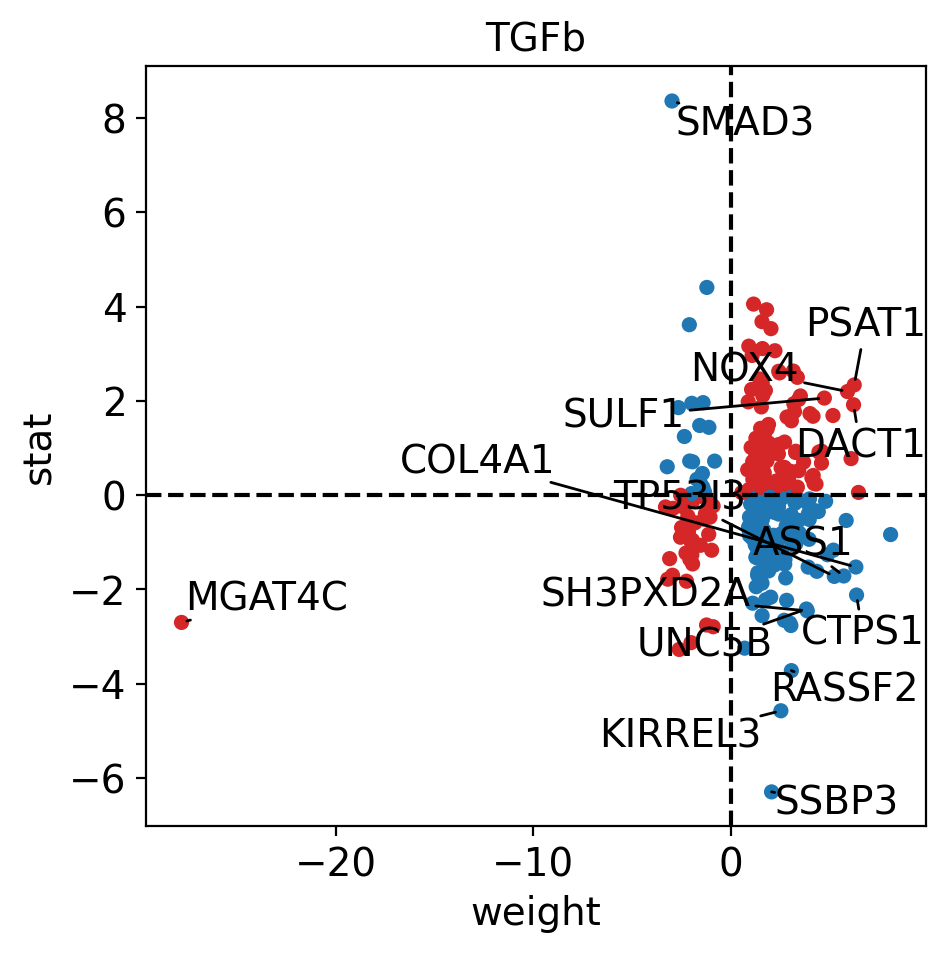

In [52]:
dc.plot_targets(
    data=results_df,
    stat='stat',
    source_name='TGFb',
    net=progeny,
    top=15
)